# Results Summary & Comparison

Compare our reproduction with the paper's reported results.

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import matplotlib.pyplot as plt
from src.visualization import save_fig

with open('../data/results_round1.pkl', 'rb') as f:
    r1 = pickle.load(f)
with open('../data/results_round2.pkl', 'rb') as f:
    r2 = pickle.load(f)

results_r1 = r1['results']
results_r2 = r2['results']
cv_r2 = r2['cv_results']

In [2]:
# Performance comparison table
print("=" * 75)
print(f"{'Model':<25} {'R1 AUC':>8} {'R1 Acc':>8} | {'R2 AUC':>8} {'R2 Acc':>8}")
print("=" * 75)
for name in results_r1:
    r1a = results_r1[name]['auc']
    r1c = results_r1[name]['accuracy']
    r2a = results_r2[name]['auc']
    r2c = results_r2[name]['accuracy']
    print(f"{name:<25} {r1a:>8.4f} {r1c:>8.4f} | {r2a:>8.4f} {r2c:>8.4f}")
print("=" * 75)
print(f"\nOur RF (4 features) 10-fold CV: AUC = {cv_r2['auc_mean']:.2f} +/- {cv_r2['auc_std']:.2f}")
print(f"Paper RF (4 features) 10-fold CV: AUC = 0.87 +/- 0.06")

Model                       R1 AUC   R1 Acc |   R2 AUC   R2 Acc
Random Forest               0.9581   0.8780 |   0.8984   0.9024
Gradient Boosting           0.9516   0.8293 |   0.9161   0.9512
XGBoost                     0.9387   0.8537 |   0.9161   0.9024
Logistic Regression         0.8774   0.8537 |   0.8452   0.8537
SVC                         0.8839   0.8780 |   0.7645   0.8780

Our RF (4 features) 10-fold CV: AUC = 0.78 +/- 0.07
Paper RF (4 features) 10-fold CV: AUC = 0.87 +/- 0.06


Saved: /home/yhm/desktop/code/anion-paper/figures/roc_comparison.png


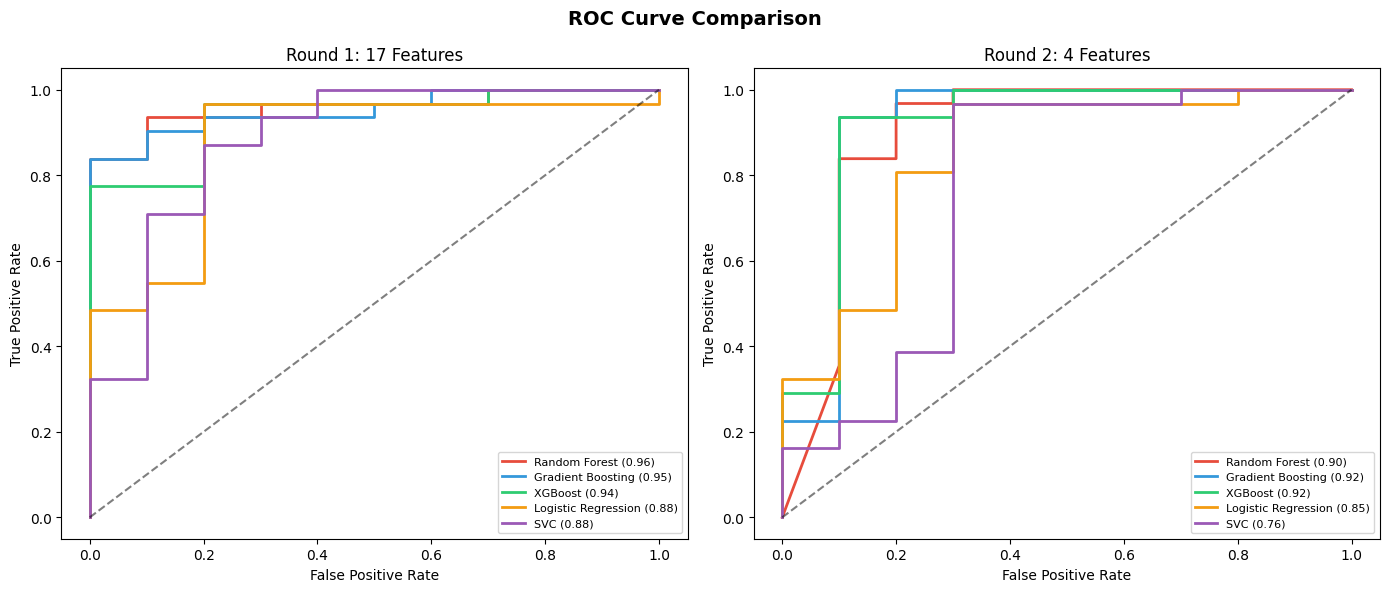

In [3]:
# Side-by-side ROC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

for (name, res), color in zip(results_r1.items(), colors):
    ax1.plot(res["fpr"], res["tpr"], label=f'{name} ({res["auc"]:.2f})', color=color, lw=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("Round 1: 17 Features"); ax1.legend(fontsize=8)

for (name, res), color in zip(results_r2.items(), colors):
    ax2.plot(res["fpr"], res["tpr"], label=f'{name} ({res["auc"]:.2f})', color=color, lw=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("Round 2: 4 Features"); ax2.legend(fontsize=8)

plt.suptitle("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, "roc_comparison.png")
plt.show()

In [4]:
# Summary
print("=" * 70)
print("REPRODUCTION SUMMARY")
print("=" * 70)
print("Paper: Xu et al., Nat. Mater. 22, 1507-1514 (2023)")
print("DOI:   10.1038/s41563-023-01705-y")
print()
print("Dataset: 267 PH anions, 19 features")
print(f"  High Eb (>3 eV): 201 (75.3%)")
print(f"  Low Eb (<=3 eV):  66 (24.7%)")
print()
print("Round 1: 17 features (removed MPI, La)")
print("Round 2: 4 features (num_O, TPSA, HBA, HOMO)")
print()
print(f"Our RF (4 features) 10-fold CV:")
print(f"  AUC:      {cv_r2['auc_mean']:.2f} +/- {cv_r2['auc_std']:.2f}")
print(f"  Accuracy: {cv_r2['acc_mean']:.2f} +/- {cv_r2['acc_std']:.2f}")
print(f"Paper RF (4 features):")
print(f"  AUC:      0.87 +/- 0.06")
print(f"  Accuracy: 0.84")
print()
print("Key guidelines (confirmed):")
print("  1. More num_O  -> stronger Eb (more Pb2+ coordination sites)")
print("  2. Larger TPSA -> stronger Eb (more hydrogen bonding)")  
print("  3. More HBA    -> stronger Eb (more H-bond acceptors)")
print("  4. Lower HOMO  -> stronger Eb (higher electronegativity)")
print("=" * 70)

REPRODUCTION SUMMARY
Paper: Xu et al., Nat. Mater. 22, 1507-1514 (2023)
DOI:   10.1038/s41563-023-01705-y

Dataset: 267 PH anions, 19 features
  High Eb (>3 eV): 201 (75.3%)
  Low Eb (<=3 eV):  66 (24.7%)

Round 1: 17 features (removed MPI, La)
Round 2: 4 features (num_O, TPSA, HBA, HOMO)

Our RF (4 features) 10-fold CV:
  AUC:      0.78 +/- 0.07
  Accuracy: 0.80 +/- 0.05
Paper RF (4 features):
  AUC:      0.87 +/- 0.06
  Accuracy: 0.84

Key guidelines (confirmed):
  1. More num_O  -> stronger Eb (more Pb2+ coordination sites)
  2. Larger TPSA -> stronger Eb (more hydrogen bonding)
  3. More HBA    -> stronger Eb (more H-bond acceptors)
  4. Lower HOMO  -> stronger Eb (higher electronegativity)
